In [1]:
import numpy as np
import pandas as pd
import pickle

import sklearn
import sklearn.preprocessing
import sklearn.model_selection

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import time

from matplotlib import pyplot as plt
import os
from copy import deepcopy

from models import *

In [2]:
with open('data/current.pkl', 'rb') as file:
    df_current = pickle.load(file)

with open('data/parameters.pkl', 'rb') as file:
    df_params = pickle.load(file)

In [3]:
df_params = df_params.rename(columns={"membrane": "diaphragm", "WW": "circuit function", "nominal width": "nominal width in mm", "voltage": "voltage in V", "pvor": "p_supply in bar", "prueck": "p_back in bar"})
df_params['nominal width in mm'] = df_params['nominal width in mm'].str.replace(',', '.').astype('float')
df_params['voltage in V'] = df_params['voltage in V'].astype('float')
df_params['p_supply in bar'] = df_params['p_supply in bar'].astype('float')
df_params['p_back in bar'] = df_params['p_back in bar'].astype('float')
df_params['ID'] = df_params['ID'].astype('int')

In [4]:
X = df_current.values
y = df_params['diaphragm'].copy()

In [5]:
enc = sklearn.preprocessing.OneHotEncoder(categories=[['AA', 'FF', 'CC']], sparse=False)
y_ohe = enc.fit_transform(y.values.reshape(-1, 1))
y_ohe

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [6]:
# Random Train-test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y_ohe, test_size=0.2, random_state=42)#, stratify=y_ohe)

In [7]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

In [8]:
cat_weights = torch.tensor([1.,4.,1.],dtype=torch.float32, device=device)

In [9]:
model = PDEInspiredModel(ts_model=RecurrentPrediction,model_channels=4)
model = model.to(device)
model(torch.tensor(X_train[:1],dtype=torch.float32, device=device))

tensor([[0.3645, 0.3730, 0.2626]], grad_fn=<SoftmaxBackward0>)

In [10]:
X_fit, X_val, y_fit, y_val = sklearn.model_selection.train_test_split(X_train, y_train, test_size=0.30, random_state=123)#, stratify=y_ohe)

history = model.fit(X_fit, y_fit, X_val, y_val, cat_weights=cat_weights)

parameter count: 151

saving model

9.876510720374654e-10
epoch 0, loss=1.5657355785369873, val. loss=1.473625659942627, val. acc.=0.1059730276465416, time: 67ms
2.6832595034775863e-09
epoch 1, loss=1.5599045753479004, val. loss=1.4924991130828857, val. acc.=0.1059730276465416, time: 38ms
3.0183000543360095e-10
epoch 2, loss=1.54836767911911, val. loss=1.4731976985931396, val. acc.=0.1059730276465416, time: 38ms
8.000771156702058e-10
epoch 3, loss=1.539320945739746, val. loss=1.4541881084442139, val. acc.=0.1059730276465416, time: 40ms
0.0
epoch 4, loss=1.5356132984161377, val. loss=1.4502421617507935, val. acc.=0.1059730276465416, time: 40ms
1.4648028345831676e-09
epoch 5, loss=1.5235182046890259, val. loss=1.4487032890319824, val. acc.=0.1059730276465416, time: 35ms
5.308600226072713e-10
epoch 6, loss=1.5311055779457092, val. loss=1.4470561742782593, val. acc.=0.1059730276465416, time: 36ms
0.0
epoch 7, loss=1.5505746006965637, val. loss=1.44548761844635, val. acc.=0.1059730276465416

0.0
epoch 66, loss=0.48982399702072144, val. loss=0.4626461863517761, val. acc.=0.8728323578834534, time: 43ms
3.0264548513514455e-05
epoch 67, loss=0.48630450665950775, val. loss=0.46839576959609985, val. acc.=0.8554913401603699, time: 43ms
5.968972345726797e-06
epoch 68, loss=0.49141770601272583, val. loss=0.4517580270767212, val. acc.=0.8959537744522095, time: 42ms
0.00019561246153898537
epoch 69, loss=0.4714447408914566, val. loss=0.47884777188301086, val. acc.=0.8362234830856323, time: 44ms

saving model

7.804122287780046e-05
epoch 70, loss=0.46716322004795074, val. loss=0.4461171627044678, val. acc.=0.9036608934402466, time: 43ms
2.786082859529415e-05
epoch 71, loss=0.4902809411287308, val. loss=0.468658447265625, val. acc.=0.8439306616783142, time: 44ms
9.118997695622966e-05
epoch 72, loss=0.4800402969121933, val. loss=0.44508635997772217, val. acc.=0.9036608934402466, time: 36ms
4.729457577923313e-05
epoch 73, loss=0.46874547004699707, val. loss=0.449502170085907, val. acc.=0.

4.0364843812312756e-05
epoch 133, loss=0.4595802128314972, val. loss=0.4593464732170105, val. acc.=0.8593448996543884, time: 43ms
0.00010682102583814412
epoch 134, loss=0.4362080544233322, val. loss=0.43403875827789307, val. acc.=0.8959537744522095, time: 44ms
3.0355315175256692e-05
epoch 135, loss=0.4357929527759552, val. loss=0.45588046312332153, val. acc.=0.8612716794013977, time: 41ms
6.074991460991441e-05
epoch 136, loss=0.43897001445293427, val. loss=0.43436986207962036, val. acc.=0.8940269947052002, time: 43ms
0.0
epoch 137, loss=0.4290570914745331, val. loss=0.4499991238117218, val. acc.=0.8612716794013977, time: 43ms
1.6730190282032709e-06
epoch 138, loss=0.4428923577070236, val. loss=0.43160077929496765, val. acc.=0.8901734352111816, time: 43ms
3.464935070951469e-05
epoch 139, loss=0.4365350902080536, val. loss=0.4378849267959595, val. acc.=0.8824662566184998, time: 45ms
0.0008177529671229422
epoch 140, loss=0.45460811257362366, val. loss=0.445907860994339, val. acc.=0.874759

0.0003747566264564739
epoch 199, loss=0.4554278999567032, val. loss=0.4271650016307831, val. acc.=0.9036608934402466, time: 41ms
0.0
epoch 200, loss=0.4351702481508255, val. loss=0.4567558765411377, val. acc.=0.8554913401603699, time: 41ms
0.0
epoch 201, loss=0.4305088669061661, val. loss=0.43852341175079346, val. acc.=0.8766859173774719, time: 36ms
1.1699402335807463e-07
epoch 202, loss=0.42573103308677673, val. loss=0.43117836117744446, val. acc.=0.8824662566184998, time: 35ms
0.00010443522478453815
epoch 203, loss=0.43195338547229767, val. loss=0.46058085560798645, val. acc.=0.8516377806663513, time: 35ms
4.93868299145106e-07
epoch 204, loss=0.42659395933151245, val. loss=0.42420220375061035, val. acc.=0.899807333946228, time: 35ms
3.9349822486656194e-05
epoch 205, loss=0.43721458315849304, val. loss=0.4412594437599182, val. acc.=0.8747591376304626, time: 38ms
0.00016838828560139518
epoch 206, loss=0.4465826451778412, val. loss=0.46919506788253784, val. acc.=0.8439306616783142, time

0.0003452362543612253
epoch 268, loss=0.43486206233501434, val. loss=0.4421346187591553, val. acc.=0.863198459148407, time: 42ms
0.00018405554146738723
epoch 269, loss=0.4425858110189438, val. loss=0.4214073717594147, val. acc.=0.8786126971244812, time: 37ms
1.6811692375995335e-06
epoch 270, loss=0.448298841714859, val. loss=0.430946409702301, val. acc.=0.8747591376304626, time: 36ms
0.00047370302490890026
epoch 271, loss=0.4108433425426483, val. loss=0.4285029470920563, val. acc.=0.8747591376304626, time: 35ms
8.912361909096944e-05
epoch 272, loss=0.4437681883573532, val. loss=0.4218968152999878, val. acc.=0.8940269947052002, time: 36ms
0.0001396680745529011
epoch 273, loss=0.43138542771339417, val. loss=0.4710300862789154, val. acc.=0.8400770425796509, time: 36ms
0.00019604110184445744
epoch 274, loss=0.4471433460712433, val. loss=0.41798022389411926, val. acc.=0.9055876731872559, time: 41ms
0.00014573492080671713
epoch 275, loss=0.42593544721603394, val. loss=0.4509578049182892, val

...

8.047829760471359e-05
epoch 9715, loss=0.6980152428150177, val. loss=0.6368299722671509, val. acc.=0.5587668418884277, time: 45ms
5.804265512665552e-08
epoch 9716, loss=0.7142096161842346, val. loss=0.6408055424690247, val. acc.=0.5587668418884277, time: 44ms
6.1523196259738455e-09
epoch 9717, loss=0.6830880641937256, val. loss=0.6363964676856995, val. acc.=0.5587668418884277, time: 46ms
0.0
epoch 9718, loss=0.7087037563323975, val. loss=0.6358627676963806, val. acc.=0.5587668418884277, time: 42ms
6.004713171137155e-08
epoch 9719, loss=0.6991464197635651, val. loss=0.6402198076248169, val. acc.=0.5587668418884277, time: 47ms
7.837435700430717e-10
epoch 9720, loss=0.6826917827129364, val. loss=0.634096622467041, val. acc.=0.5587668418884277, time: 45ms
6.684296538495005e-08
epoch 9721, loss=0.6941640675067902, val. loss=0.6345144510269165, val. acc.=0.5587668418884277, time: 48ms
1.7705801269585209e-07
epoch 9722, loss=0.6956437528133392, val. loss=0.6302980780601501, val. acc.=0.558766

5.625004351195173e-10
epoch 9780, loss=0.69153892993927, val. loss=0.6384575963020325, val. acc.=0.5587668418884277, time: 44ms
0.0
epoch 9781, loss=0.6921890377998352, val. loss=0.6364722847938538, val. acc.=0.5587668418884277, time: 41ms
9.747760287837082e-08
epoch 9782, loss=0.6974990367889404, val. loss=0.6328058242797852, val. acc.=0.5587668418884277, time: 40ms
1.5884548787425956e-08
epoch 9783, loss=0.6892451345920563, val. loss=0.63798588514328, val. acc.=0.5587668418884277, time: 40ms
6.875028475405998e-07
epoch 9784, loss=0.6978971660137177, val. loss=0.638767421245575, val. acc.=0.5587668418884277, time: 42ms
3.290957228951896e-10
epoch 9785, loss=0.6770125031471252, val. loss=0.6364096999168396, val. acc.=0.5587668418884277, time: 41ms
0.0
epoch 9786, loss=0.6917840838432312, val. loss=0.6340381503105164, val. acc.=0.5587668418884277, time: 52ms
0.0
epoch 9787, loss=0.7046884298324585, val. loss=0.631897509098053, val. acc.=0.5587668418884277, time: 51ms
3.338886358505988e-

0.016115534681475197
epoch 9847, loss=0.6762684881687164, val. loss=0.6301648616790771, val. acc.=0.5587668418884277, time: 54ms
2.542939228078467e-07
epoch 9848, loss=0.7003707587718964, val. loss=0.6332607269287109, val. acc.=0.5587668418884277, time: 51ms
2.766963556055657e-07
epoch 9849, loss=0.6684940457344055, val. loss=0.6371006965637207, val. acc.=0.5587668418884277, time: 52ms
2.957481048254662e-12
epoch 9850, loss=0.6790505051612854, val. loss=0.6332986354827881, val. acc.=0.5587668418884277, time: 52ms
1.396502650408138e-06
epoch 9851, loss=0.6953385770320892, val. loss=0.6311295032501221, val. acc.=0.5587668418884277, time: 53ms
1.7709976418700535e-06
epoch 9852, loss=0.6812400817871094, val. loss=0.6334941387176514, val. acc.=0.5587668418884277, time: 54ms
2.526003981984104e-06
epoch 9853, loss=0.6857969462871552, val. loss=0.6390478610992432, val. acc.=0.5587668418884277, time: 47ms
2.93988930977207e-07
epoch 9854, loss=0.689198225736618, val. loss=0.6407939791679382, val

1.7617263438296504e-05
epoch 9914, loss=0.7061477899551392, val. loss=0.6475782990455627, val. acc.=0.5587668418884277, time: 51ms
0.0
epoch 9915, loss=0.6974020898342133, val. loss=0.6469584107398987, val. acc.=0.5587668418884277, time: 47ms
7.542849171926491e-07
epoch 9916, loss=0.6875098049640656, val. loss=0.6382925510406494, val. acc.=0.5587668418884277, time: 44ms
0.0
epoch 9917, loss=0.6778018474578857, val. loss=0.6279927492141724, val. acc.=0.5587668418884277, time: 46ms
4.352798157469806e-07
epoch 9918, loss=0.6846442520618439, val. loss=0.6268448233604431, val. acc.=0.5587668418884277, time: 44ms
7.028106203676998e-07
epoch 9919, loss=0.6892298460006714, val. loss=0.6310606002807617, val. acc.=0.5587668418884277, time: 46ms
1.3117476527213512e-07
epoch 9920, loss=0.6687536537647247, val. loss=0.6348094940185547, val. acc.=0.5587668418884277, time: 45ms
0.0
epoch 9921, loss=0.6937571465969086, val. loss=0.6414350271224976, val. acc.=0.5587668418884277, time: 44ms
0.0
epoch 99

7.571613891421691e-10
epoch 9984, loss=0.6645711362361908, val. loss=0.6409963369369507, val. acc.=0.5587668418884277, time: 45ms
0.00022219329991912673
epoch 9985, loss=0.6843155920505524, val. loss=0.630168080329895, val. acc.=0.5587668418884277, time: 47ms
1.9593137494666735e-06
epoch 9986, loss=0.6833192706108093, val. loss=0.6254781484603882, val. acc.=0.5587668418884277, time: 46ms
2.880347210520995e-06
epoch 9987, loss=0.6923904716968536, val. loss=0.6257632970809937, val. acc.=0.5587668418884277, time: 46ms
3.0424680552698646e-09
epoch 9988, loss=0.6794452965259552, val. loss=0.6307293772697449, val. acc.=0.5587668418884277, time: 47ms
0.0
epoch 9989, loss=0.6718469858169556, val. loss=0.6406503915786743, val. acc.=0.5587668418884277, time: 53ms
7.557458161500108e-07
epoch 9990, loss=0.6673066020011902, val. loss=0.6335430145263672, val. acc.=0.5587668418884277, time: 53ms
1.1546936047324152e-05
epoch 9991, loss=0.7103116810321808, val. loss=0.6301710605621338, val. acc.=0.5587

In [11]:
model.load_state_dict(torch.load(('./pde_model.pt')))

<All keys matched successfully>

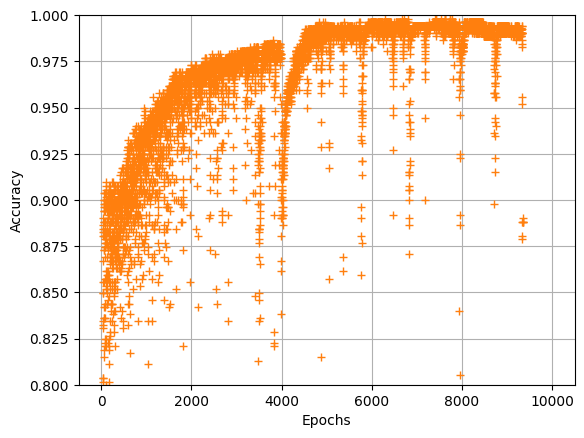

In [12]:
# acc = history.history['accuracy']
val_acc = np.array(history)[:,2]
epochs = range(1, len(val_acc) + 1)

# plt.plot(epochs, acc, 'b+')
plt.plot(epochs, val_acc, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim((0.8,1))
plt.grid()
plt.show()

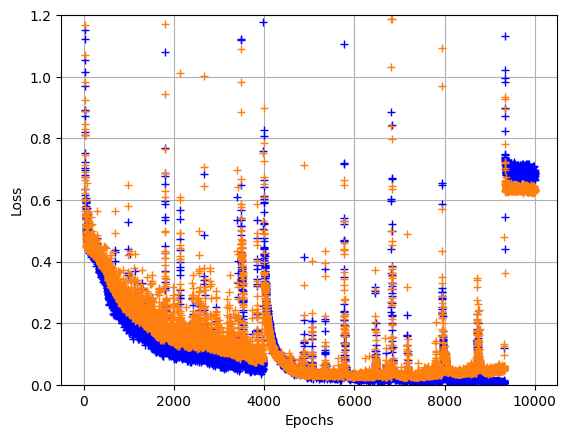

In [13]:
loss_values = np.array(history)[:,0]
val_loss_values = np.array(history)[:,1]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'b+')
plt.plot(epochs, val_loss_values, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim((0.,1.2))
plt.grid()
plt.show()

In [14]:
y_cv = model(torch.tensor(X_train, dtype=torch.float32)).detach().numpy()

In [15]:
new = np.zeros(y_cv.shape)
for i, j in enumerate(y_cv):
    new[i][np.argmax(j)] = 1

y_cv_class = new.astype('int')
y_cv_class

array([[1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       ...,
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0]])

In [16]:
# Calculate scores
r2_score_train = sklearn.metrics.r2_score(y_train, y_cv_class)
ev_score_train = sklearn.metrics.explained_variance_score(y_train, y_cv_class)
mse_train = sklearn.metrics.mean_squared_error(y_train, y_cv_class)
acc_score_train = sklearn.metrics.accuracy_score(y_train, y_cv_class)
precision_score_train_None = sklearn.metrics.precision_score(y_train, y_cv_class, average=None)
recall_score_train_None = sklearn.metrics.recall_score(y_train, y_cv_class, average=None)
precision_score_train_macro = sklearn.metrics.precision_score(y_train, y_cv_class, average='macro')
recall_score_train_macro= sklearn.metrics.recall_score(y_train, y_cv_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_train))
print(f"Precision: {np.array2string(precision_score_train_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_train_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_train_macro}")
print(f"Recall macro: {recall_score_train_macro}")

R2 Score: 0.9902
Explained variance score: 0.9902
Mean squared error: 0.0019
Accuracy Score: 0.9971
Precision: [0.9958 0.9910 1.0000]
Recall: [0.9972 1.0000 0.9962]
Precision macro: 0.9956039936172761
Recall macro: 0.9978079000317696


### Train quality

In [17]:
class_number = len(y_cv_class[0])
cm_train = np.zeros((class_number, class_number))
for tr, pre in zip(y_train, y_cv_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_train[i_true][i_pred] += 1
    
cm_train

array([[708.,   2.,   0.],
       [  0., 221.,   0.],
       [  3.,   0., 795.]])

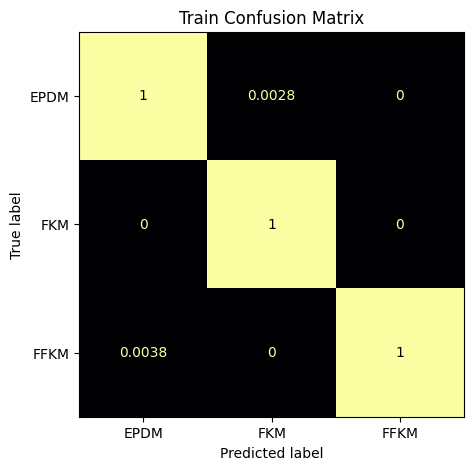

In [18]:
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_train[0] / cm_train[0].sum(), 
                                                        cm_train[1] / cm_train[1].sum(), 
                                                        cm_train[2] / cm_train[2].sum()]), 
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Train Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

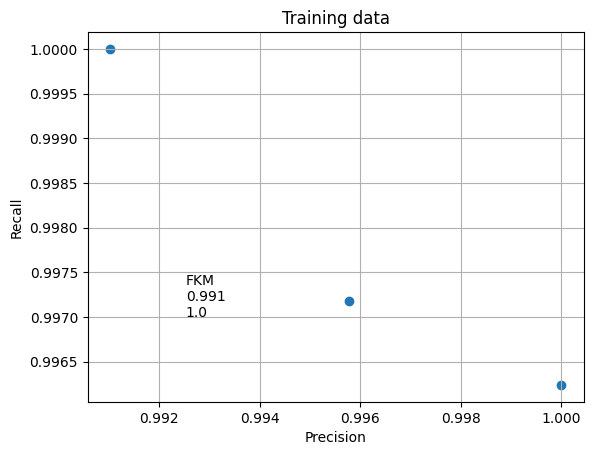

In [19]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_train_None[0],3))+'\n'+str(round(recall_score_train_None[0],3)),
     'FKM\n'+str(round(precision_score_train_None[1],3))+'\n'+str(round(recall_score_train_None[1],3)), 
     'FFKM\n'+str(round(precision_score_train_None[2],3))+'\n'+str(round(recall_score_train_None[2],3))]

ax.scatter(precision_score_train_None, recall_score_train_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Training data')

ax.annotate(n[0], (precision_score_train_None[0]+0.0015, recall_score_train_None[0]-0.009)) # EPDM
ax.annotate(n[1], (precision_score_train_None[1]+0.0015, recall_score_train_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_train_None[2]-0.008, recall_score_train_None[2]-0.011)) # FFKM
plt.show()

## Test model

In [20]:
y_predict = model(torch.tensor(X_test,dtype=torch.float32)).detach().numpy()
y_predict

array([[9.9732131e-01, 1.3958632e-07, 2.6785601e-03],
       [9.9741578e-01, 1.4463538e-06, 2.5828162e-03],
       [5.0787543e-09, 1.6163930e-09, 1.0000000e+00],
       ...,
       [3.0392119e-10, 7.7594246e-05, 9.9992239e-01],
       [4.1535746e-05, 9.9995685e-01, 1.6549415e-06],
       [5.1007876e-10, 1.8501467e-07, 9.9999976e-01]], dtype=float32)

### Test metrics

In [21]:
new = np.zeros(y_predict.shape)
for i, j in enumerate(y_predict): # enumerate, itterieren durch Liste i = index, j = Wert
    new[i][np.argmax(j)] = 1

y_predict_class = new.astype('int')
y_predict_class

array([[1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1]])

In [22]:
# Calculate scores
r2_score_test = sklearn.metrics.r2_score(y_test, y_predict_class)
ev_score_test = sklearn.metrics.explained_variance_score(y_test, y_predict_class)
mse_test = sklearn.metrics.mean_squared_error(y_test, y_predict_class)
acc_score_test = sklearn.metrics.accuracy_score(y_test, y_predict_class)
precision_score_test_None = sklearn.metrics.precision_score(y_test, y_predict_class, average=None)
recall_score_test_None = sklearn.metrics.recall_score(y_test, y_predict_class, average=None)
precision_score_test_macro = sklearn.metrics.precision_score(y_test, y_predict_class, average='macro')
recall_score_test_macro= sklearn.metrics.recall_score(y_test, y_predict_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_test))
print(f"Precision: {np.array2string(precision_score_test_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_test_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_test_macro}")
print(f"Recall macro: {recall_score_test_macro}")

R2 Score: 0.9902
Explained variance score: 0.9902
Mean squared error: 0.0019
Accuracy Score: 0.9931
Precision: [0.9944 0.9565 1.0000]
Recall: [0.9888 0.9778 1.0000]
Precision macro: 0.9836345872007817
Recall macro: 0.9888681978067453


### Test quality

In [23]:
class_number = len(y_predict_class[0])
cm_test = np.zeros((class_number, class_number))
for tr, pre in zip(y_test, y_predict_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_test[i_true][i_pred] += 1
    
cm_test

array([[177.,   2.,   0.],
       [  1.,  44.,   0.],
       [  0.,   0., 209.]])

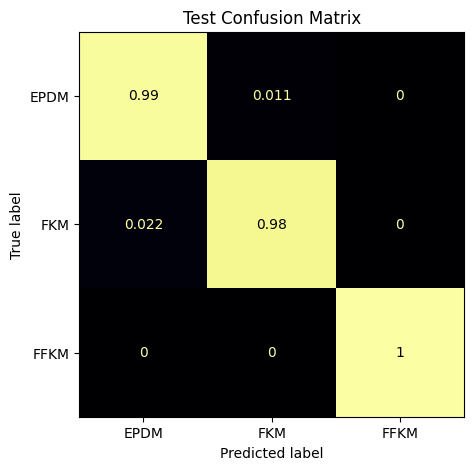

In [24]:
# sklearn.metrics.ConfusionMatrixDisplay(cm_train).plot()
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_test[0] / cm_test[0].sum(), 
                                                 cm_test[1] / cm_test[1].sum(), 
                                                 cm_test[2] / cm_test[2].sum()]),
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Test Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

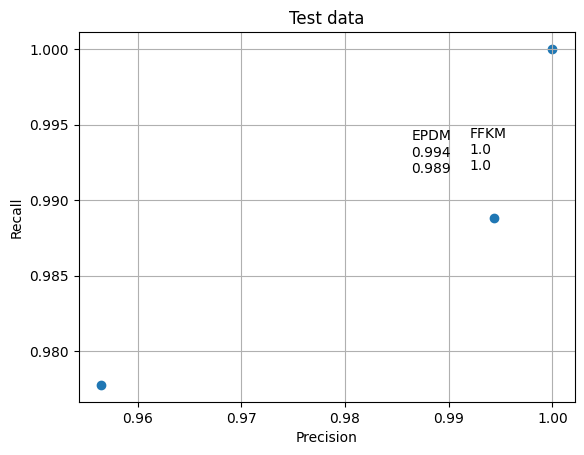

In [25]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_test_None[0],3))+'\n'+str(round(recall_score_test_None[0],3)),
     'FKM\n'+str(round(precision_score_test_None[1],3))+'\n'+str(round(recall_score_test_None[1],3)), 
     'FFKM\n'+str(round(precision_score_test_None[2],3))+'\n'+str(round(recall_score_test_None[2],3))]

ax.scatter(precision_score_test_None, recall_score_test_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Test data')

ax.annotate(n[0], (precision_score_test_None[0]-0.008, recall_score_test_None[0]+0.003)) # EPDM
ax.annotate(n[1], (precision_score_test_None[1]+0.0015, recall_score_test_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_test_None[2]-0.008, recall_score_test_None[2]-0.008)) # FFKM
plt.show()

In [27]:
# torch.save(deepcopy(model.state_dict()), 'RecurrentModel.pt')